# Crypto Portfolio Construction



> **How to add BTC/ETH to a traditional asset portfolio without forecasting future crypto returns, using risk contribution control and cash dilution.**

The main idea is based on Johansson and Boyd's *Simple and Effective Portfolio Construction with Crypto Assets*.

This report compares four strategies:

1. **Traditional Equal Weight**: invests only in traditional assets and serves as the benchmark without crypto exposure;
2. **Fixed 90/10**: allocates a fixed 90% to traditional assets and 10% to crypto assets;
3. **DD90/10**: maintains the fixed 90/10 relative allocation, but dynamically increases the cash position according to the estimated volatility;
4. **CRA Combined**: optimizes the weights of traditional assets and crypto assets using Constrained Risk Allocation.



In [1]:
# %pip install yfinance pandas numpy scipy matplotlib

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

try:
    import yfinance as yf
except Exception:
    yf = None

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

START_DATE = "2017-09-08"
END_DATE = pd.Timestamp.today().strftime("%Y-%m-%d")

# traditional industry portfolios
TRAD_TICKERS = ["XLY", "XLI", "XLK", "XLV"]   # consumer, industrial, technology, healthcare
CRYPTO_TICKERS = ["BTC-USD", "ETH-USD"]
ALL_TICKERS = TRAD_TICKERS + CRYPTO_TICKERS

TARGET_VOL = 0.10       # Target annualized volatility: 10%
CRYPTO_CAP = 0.10       # The combined weight of BTC and ETH is capped at 10%.
LOOKBACK = 252          # The covariance matrix is estimated using approximately one year of historical data.
HALFLIFE = 63           # EWMA half-life
ANNUALIZATION = 252     # annualization factor based on ETF trading days
REBALANCE_EVERY = 21    # The portfolio weights are recalculated every 21 trading days.

print("Assets:", ALL_TICKERS)
print("Target volatility:", TARGET_VOL)
print("Crypto cap:", CRYPTO_CAP)
print("Rebalance every", REBALANCE_EVERY, "trading days")


Assets: ['XLY', 'XLI', 'XLK', 'XLV', 'BTC-USD', 'ETH-USD']
Target volatility: 0.1
Crypto cap: 0.1
Rebalance every 21 trading days


## 1. Introduction: Why do we not forecast returns?

The expected returns of crypto assets are difficult to estimate because BTC and ETH prices are highly volatile and their historical returns are unstable.

Therefore, this report adopts a risk-based portfolio construction approach:

> Instead of predicting how much BTC or ETH will rise, we control how much they contribute to total portfolio risk.

This is the central idea of the report: **the high volatility of crypto does not necessarily mean that crypto cannot be allocated at all; the key is to control its risk contribution.**


## 2. Mathematical Core: Portfolio Risk and Risk Contribution

Suppose there are $n$ assets, with weight vector

$$
w=(w_1,\dots,w_n),
$$

and the covariance matrix of asset returns is

$$
\Sigma.
$$

The portfolio variance, or portfolio risk, can be written as:

$$
\sigma_p^2 = w^T\Sigma w.
$$

This total risk can be decomposed into the contribution of each asset:

$$
w^T\Sigma w = \sum_{i=1}^n w_i(\Sigma w)_i.
$$

Therefore, the **risk contribution** of asset $i$ is defined as:

$$
RC_i = w_i(\Sigma w)_i.
$$



If we want asset $i$ to contribute a proportion $\rho_i$ of total risk, we require:

$$
w_i(\Sigma w)_i = \rho_i w^T\Sigma w.
$$

When $\rho_i=1/n$, this becomes risk parity, meaning that each asset contributes the same proportion of total risk.


## 3. CRA: Mathematical Model of Constrained Risk Allocation

The goal of CRA is to make each asset contribute risk according to a specified proportion while satisfying realistic constraints.

The CRA model used in this report is:

$$
\begin{aligned}
\text{minimize} \quad & c \\
\text{subject to} \quad
& w\ge 0,\quad c\ge 0,\\
& \mathbf{1}^T w+c=1,\\
& w_i(\Sigma w)_i=\rho_i w^T\Sigma w,\\
& w^T\Sigma w\le \sigma^2,\\
& w_{BTC}+w_{ETH}\le 0.10.
\end{aligned}
$$

Here:

- $w$ is the weight vector of risky assets;
- $c$ is the cash weight;
- $\sigma=10\%$ is the target annualized volatility;
- $w_{BTC}+w_{ETH}\le 0.10$ is the crypto cap;
- minimizing $c$ means investing as much as possible in risky assets, while holding as little cash as possible, subject to the risk constraints.


## 4. Convex Optimization Solution for CRA

Solving CRA directly is difficult because the risk contribution condition is nonlinear. Here we uses a two-step method.

First, solve the following convex optimization problem:

$$
x^\star = \arg\min_{x>0}\left(\frac{1}{2}x^T\Sigma x-\sum_i \rho_i\log x_i\right).
$$

This problem first finds a "relative allocation direction" $x^\star$.

From the first-order condition, we obtain:

$$
(\Sigma x^\star)_i-\frac{\rho_i}{x_i^\star}=0,
$$

so:

$$
x_i^\star(\Sigma x^\star)_i=\rho_i.
$$

This shows that $x^\star$ corresponds to the target risk contribution structure.

Second, scale this direction into actual portfolio weights:

$$
w^\star=\alpha^\star x^\star.
$$

where:

$$
\alpha^\star=\min\left\{
\frac{1}{\mathbf{1}^Tx^\star},
\frac{\sigma}{\sqrt{(x^\star)^T\Sigma x^\star}},
\frac{0.10}{x^\star_{BTC}+x^\star_{ETH}}
\right\}.
$$



> CRA first uses convex optimization to determine the relative risk allocation direction among assets, and then uses a scaling coefficient to determine how much capital should be invested overall, with the remaining capital held as cash.


## 5. DD90/10: A Simpler Version of CRA

CRA is more complete, but it is also slightly more complex to explain. We also proposes a simpler method called the **Dynamically Diluted 90/10 Portfolio**, abbreviated as DD90/10.

First, fix the base portfolio:

$$
90\%\ \text{traditional assets}+10\%\ \text{crypto assets}.
$$

In this report:

$$
XLY=XLI=XLK=XLV=22.5\%, \qquad BTC=ETH=5\%.
$$

Then estimate the recent volatility of this base portfolio and denote it by $\hat\sigma_t$. If the target volatility is $\sigma_{target}$, define:

$$
\lambda_t=\min\left(1,\frac{\sigma_{target}}{\hat\sigma_t}\right).
$$

The final weights are:

$$
w_t=\lambda_t b, \qquad c_t=1-\lambda_t.
$$

The intuition is:

- if market volatility is low, $\lambda_t=1$, so the strategy is fully invested in the 90/10 portfolio;
- if market volatility is high, $\lambda_t<1$, so the strategy reduces risky assets and increases cash.


## 6. Data: Downloading Prices and Computing Returns

In the formal report, the data are downloaded through `yfinance`. The selected assets are:

- Traditional assets: XLY, XLI, XLK, XLV;
- Crypto assets: BTC-USD, ETH-USD.

In [3]:
def make_demo_returns(start=START_DATE, periods=1500, seed=7):
    """If internet access is unavailable, use simulated data so that the notebook can still run. For the formal report, rerun the notebook with real data."""
    rng = np.random.default_rng(seed)
    dates = pd.bdate_range(start=start, periods=periods)
    vols = np.array([0.18, 0.17, 0.22, 0.16, 0.70, 0.85]) / np.sqrt(ANNUALIZATION)
    corr = np.array([
        [1.00, .75, .70, .65, .25, .25],
        [.75, 1.00, .65, .60, .25, .25],
        [.70, .65, 1.00, .55, .30, .30],
        [.65, .60, .55, 1.00, .20, .20],
        [.25, .25, .30, .20, 1.00, .65],
        [.25, .25, .30, .20, .65, 1.00],
    ])
    cov = np.outer(vols, vols) * corr
    mean = np.array([.07, .06, .09, .06, .18, .22]) / ANNUALIZATION
    rets = rng.multivariate_normal(mean, cov, size=len(dates))
    return pd.DataFrame(rets, index=dates, columns=ALL_TICKERS)


def download_returns():
    if yf is None:
        print("yfinance not available. Using demo simulated data.")
        return make_demo_returns(), "demo"
    try:
        raw = yf.download(ALL_TICKERS, start=START_DATE, end=END_DATE, auto_adjust=True, progress=False, timeout=10)
        if raw.empty:
            raise ValueError("No data downloaded.")
        if isinstance(raw.columns, pd.MultiIndex):
            prices = raw["Close"].copy()
        else:
            prices = raw.copy()
        prices = prices[ALL_TICKERS].dropna(how="all")
        equity_calendar = prices[TRAD_TICKERS].dropna().index
        prices = prices.reindex(equity_calendar).ffill().dropna()
        returns = prices.pct_change().dropna()
        print(f"Downloaded real data from {returns.index[0].date()} to {returns.index[-1].date()}.")
        return returns, "real"
    except Exception as e:
        print("Could not download real data. Using demo simulated data instead.")
        print("Reason:", repr(e))
        return make_demo_returns(), "demo"

returns, DATA_MODE = download_returns()
print("DATA_MODE =", DATA_MODE)
returns.head()


Downloaded real data from 2017-11-10 to 2026-06-23.
DATA_MODE = real


Ticker,XLY,XLI,XLK,XLV,BTC-USD,ETH-USD
Date,,,,,,
2017-11-10,0.003368,0.001410,0.000000,-0.006485,-0.073554,-0.067411
2017-11-13,0.003356,-0.003378,-0.000315,0.000985,-0.008862,0.058355
2017-11-14,0.000863,-0.002682,-0.002048,-0.004060,0.011626,0.066037
2017-11-15,-0.004312,-0.005664,-0.007419,-0.002841,0.102444,-0.012659
2017-11-16,0.008337,0.009398,0.013995,0.010406,0.076023,-0.007298


### 

The table above shows the daily returns of each asset. Each column corresponds to one asset, and each row corresponds to one trading day.


## 7. Figure 1: Cumulative Performance of Individual Assets

First, we examine how much one dollar invested in each asset would grow to from the starting date.


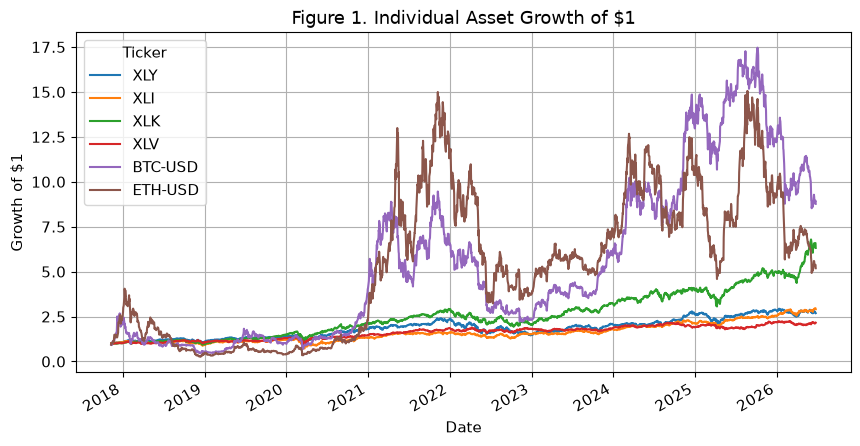

In [4]:
nav_assets = (1 + returns).cumprod()
ax = nav_assets.plot(title="Figure 1. Individual Asset Growth of $1")
ax.set_ylabel("Growth of $1")
plt.show()


### Explanation of Figure 1

The purpose of this figure is not to directly determine the portfolio allocation, but to first observe the basic characteristics of each asset.

In general, the curves of crypto assets are more volatile than those of traditional assets. They may rise more, but they may also experience much larger drawdowns. This suggests that if BTC and ETH are added using fixed capital weights, the portfolio risk may become dominated by crypto. Therefore, later sections use risk contribution, a crypto cap, and cash dilution to control risk.


## 8. Utility Functions: EWMA Covariance, Risk Contribution, and Performance
- `ewma_cov_matrix`: estimates the annualized covariance matrix from recent returns;
- `risk_contribution`: computes each asset's risk contribution share;
- `performance_table`: computes annualized return, annualized volatility, Sharpe ratio, and maximum drawdown.


In [5]:
def ewma_cov_matrix(ret_window, halflife=HALFLIFE):
    """Exponentially weighted covariance matrix, annualized."""
    X = ret_window.values
    n = len(ret_window)
    decay = np.log(2) / halflife
    weights = np.exp(-decay * np.arange(n-1, -1, -1))
    weights = weights / weights.sum()
    mean = np.average(X, axis=0, weights=weights)
    Xc = X - mean
    cov = (Xc * weights[:, None]).T @ Xc
    return pd.DataFrame(cov * ANNUALIZATION, index=ret_window.columns, columns=ret_window.columns)


def risk_contribution(w, cov):
    """Return risk contribution shares."""
    w = pd.Series(w, index=cov.index).fillna(0.0)
    sigma_w = cov.values @ w.values
    rc = w.values * sigma_w
    total = float(w.values @ cov.values @ w.values)
    if total <= 1e-12:
        return pd.Series(0.0, index=cov.index)
    return pd.Series(rc / total, index=cov.index)


def max_drawdown(nav):
    peak = nav.cummax()
    dd = nav / peak - 1
    return dd.min()


def performance_table(strategy_returns, strategy_weights=None):
    rows = []
    for name in strategy_returns.columns:
        r = strategy_returns[name].dropna()
        nav = (1 + r).cumprod()
        ann_return = nav.iloc[-1] ** (ANNUALIZATION / len(r)) - 1
        ann_vol = r.std() * np.sqrt(ANNUALIZATION)
        sharpe = ann_return / ann_vol if ann_vol > 1e-12 else np.nan
        mdd = max_drawdown(nav)
        row = {
            "Annual Return": ann_return,
            "Annual Vol": ann_vol,
            "Sharpe": sharpe,
            "Max Drawdown": mdd,
        }
        if strategy_weights is not None and name in strategy_weights:
            W = strategy_weights[name]
            row["Avg Cash"] = 1 - W.sum(axis=1).mean()
            row["Avg Crypto Weight"] = W[CRYPTO_TICKERS].sum(axis=1).mean() if set(CRYPTO_TICKERS).issubset(W.columns) else 0.0
        rows.append(pd.Series(row, name=name))
    return pd.DataFrame(rows)


## 9. CRA Solver 

The following function implements the two-step CRA method:

1. solve a convex optimization problem to obtain the direction $x^\star$;
2. use $\alpha^\star$ to scale the direction so that the weights satisfy the budget constraint, target volatility constraint, and crypto cap.


In [6]:
def solve_cra_weights(cov, target_vol=TARGET_VOL, crypto_cap=CRYPTO_CAP, rho=None):
    assets = list(cov.index)
    n = len(assets)
    Sigma = cov.values + 1e-8 * np.eye(n)  # small jitter for numerical stability
    if rho is None:
        rho = np.ones(n) / n
    rho = np.asarray(rho)

    # Let x = exp(y), so x is automatically positive.
    def obj(y):
        x = np.exp(y)
        return 0.5 * x @ Sigma @ x - rho @ y

    def grad(y):
        x = np.exp(y)
        return x * (Sigma @ x) - rho

    res = minimize(obj, np.zeros(n), jac=grad, method="BFGS", options={"maxiter": 500, "gtol": 1e-8})
    x = np.exp(res.x)

    bounds = []
    labels = []

    # 1. budget: sum(alpha*x) <= 1
    bounds.append(1.0 / x.sum())
    labels.append("budget")

    # 2. target volatility: sqrt((alpha*x)' Sigma (alpha*x)) <= target_vol
    vol_x = np.sqrt(x @ Sigma @ x)
    bounds.append(target_vol / vol_x)
    labels.append("target_vol")

    # 3. crypto cap: alpha*(x_BTC + x_ETH) <= crypto_cap
    crypto_idx = [assets.index(t) for t in CRYPTO_TICKERS if t in assets]
    crypto_x = x[crypto_idx].sum() if crypto_idx else 0
    if crypto_x > 1e-12:
        bounds.append(crypto_cap / crypto_x)
        labels.append("crypto_cap")

    alpha = float(np.min(bounds))
    binding = labels[int(np.argmin(bounds))]
    w = pd.Series(alpha * x, index=assets)
    return w, binding


## 10. Four Strategies and Backtesting 

This report we uses monthly rebalancing, meaning that the weights are recalculated approximately every 21 trading days. 

The four strategies are:

1. **Traditional EW**: equal weight among traditional assets, without buying crypto;
2. **Fixed 90/10**: fixed 90% traditional assets and 10% crypto assets;
3. **DD90/10**: keeps the relative 90/10 allocation unchanged, but adjusts total exposure according to volatility;
4. **CRA Combined**: optimizes all asset weights using CRA.


In [7]:
def base_weights_fixed_9010():
    w = pd.Series(0.0, index=ALL_TICKERS)
    w[TRAD_TICKERS] = 0.90 / len(TRAD_TICKERS)
    w[CRYPTO_TICKERS] = 0.10 / len(CRYPTO_TICKERS)
    return w


def base_weights_traditional_equal():
    w = pd.Series(0.0, index=ALL_TICKERS)
    w[TRAD_TICKERS] = 1.0 / len(TRAD_TICKERS)
    return w


def run_backtest(returns):
    strategy_names = ["Traditional EW", "Fixed 90/10", "DD90/10", "CRA Combined"]
    strat_returns = []
    weights = {name: [] for name in strategy_names}
    dates = []
    bindings = []

    b_9010 = base_weights_fixed_9010()
    b_trad = base_weights_traditional_equal()
    current_weights = {name: None for name in strategy_names}
    current_binding = None

    for i in range(LOOKBACK, len(returns)):
        date = returns.index[i]
        hist = returns.iloc[i-LOOKBACK:i]
        today_ret = returns.iloc[i]

        # Recalculate the weights every REBALANCE_EVERY trading days.
        if (i - LOOKBACK) % REBALANCE_EVERY == 0 or current_weights["CRA Combined"] is None:
            cov = ewma_cov_matrix(hist)

            # Traditional Equal Weight
            w_trad = b_trad.copy()

            # Fixed 90/10
            w_fixed = b_9010.copy()

            # DD90/10: scale 90/10 by estimated volatility
            vol_9010 = np.sqrt(b_9010.values @ cov.loc[ALL_TICKERS, ALL_TICKERS].values @ b_9010.values)
            lam = min(1.0, TARGET_VOL / vol_9010) if vol_9010 > 1e-12 else 1.0
            w_dd = lam * b_9010

            # CRA Combined
            w_cra, current_binding = solve_cra_weights(cov.loc[ALL_TICKERS, ALL_TICKERS])

            current_weights = {
                "Traditional EW": w_trad,
                "Fixed 90/10": w_fixed,
                "DD90/10": w_dd,
                "CRA Combined": w_cra.reindex(ALL_TICKERS).fillna(0.0),
            }

        W = current_weights
        strat_returns.append({name: float(W[name].values @ today_ret[ALL_TICKERS].values) for name in strategy_names})
        for name in strategy_names:
            weights[name].append(W[name])
        dates.append(date)
        bindings.append(current_binding)

    strat_returns = pd.DataFrame(strat_returns, index=dates)
    weights = {name: pd.DataFrame(weights[name], index=dates) for name in strategy_names}
    bindings = pd.Series(bindings, index=dates, name="CRA Binding Constraint")
    nav = (1 + strat_returns).cumprod()
    return strat_returns, nav, weights, bindings

strategy_returns, nav, weights, bindings = run_backtest(returns)
perf = performance_table(strategy_returns, weights)
perf


,Annual Return,Annual Vol,Sharpe,Max Drawdown,Avg Cash,Avg Crypto Weight
Traditional EW,0.154879,0.201519,0.768558,-0.337106,0.000000,0.000000
Fixed 90/10,0.198011,0.214610,0.922655,-0.341444,0.000000,0.100000
DD90/10,0.068191,0.121317,0.562089,-0.269862,0.453082,0.054692
CRA Combined,0.069393,0.120451,0.576113,-0.264533,0.452737,0.074899


### 
- **Annual Return**: annualized return;
- **Annual Vol**: annualized volatility, used to measure risk;
- **Sharpe**: annualized return divided by annualized volatility, measuring risk-adjusted performance;
- **Max Drawdown**: maximum drawdown, showing the largest decline from a historical peak;
- **Avg Cash**: average cash weight;
- **Avg Crypto Weight**: average combined weight of BTC and ETH.


## 11. Figure 2: NAV Curves of the Four Strategies

The following figure compares how one dollar invested at the beginning would grow under different strategies.


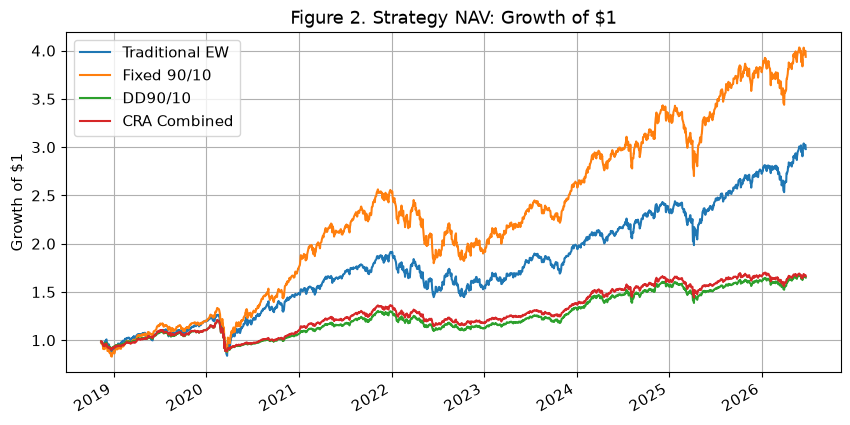

In [8]:
ax = nav.plot(title="Figure 2. Strategy NAV: Growth of $1")
ax.set_ylabel("Growth of $1")
plt.show()


### Explanation of Figure 2

This figure shows the long-term cumulative performance of the four strategies.

- **Traditional EW** is the benchmark without crypto exposure;
- **Fixed 90/10** shows the effect of simply adding 10% crypto;
- **DD90/10** shows the performance after dynamic cash dilution;
- **CRA Combined** shows the performance after risk allocation optimization.


## 12. Figure 3: Drawdowns of the Four Strategies

Drawdown measures how much the NAV falls from its historical peak.


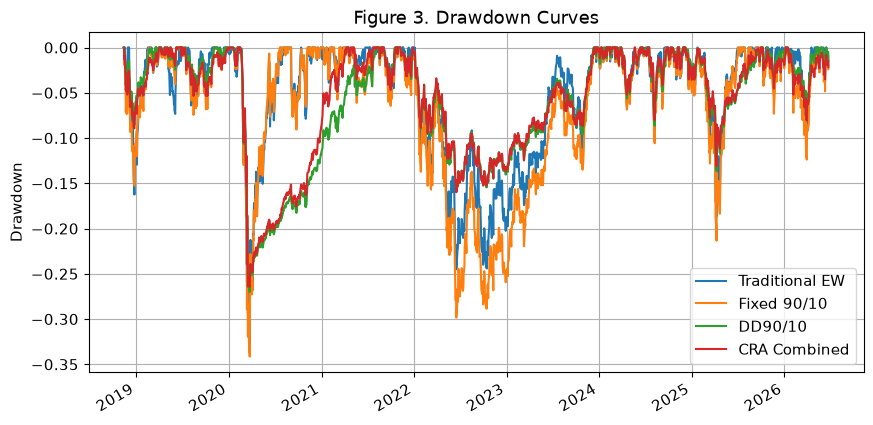

In [9]:
drawdown = nav / nav.cummax() - 1
ax = drawdown.plot(title="Figure 3. Drawdown Curves")
ax.set_ylabel("Drawdown")
plt.show()


### Explanation of Figure 3

This figure explains risk more clearly than the NAV figure.

> Fixed crypto exposure may improve growth, but it can also increase drawdown. CRA and DD90/10 are designed to reduce this problem by controlling total risk exposure.


## 13. Figure 4: Asset Weights of CRA Combined

Next, we examine how much weight CRA assigns to each asset in each period.


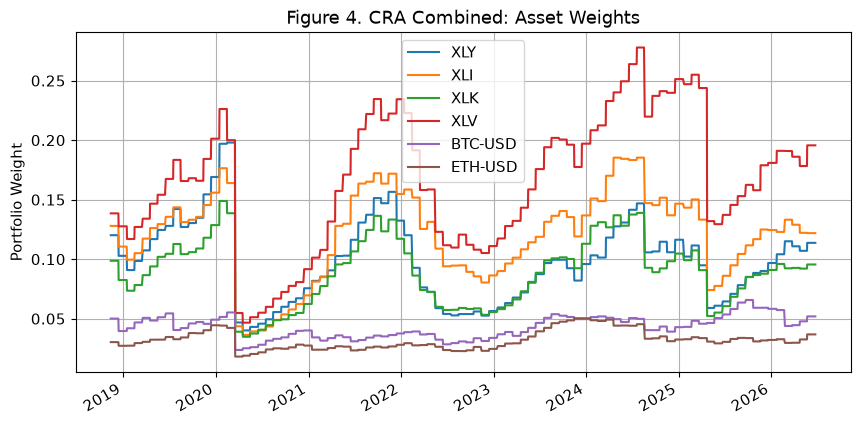

In [10]:
cra_w = weights["CRA Combined"]
ax = cra_w.plot(title="Figure 4. CRA Combined: Asset Weights")
ax.set_ylabel("Portfolio Weight")
plt.show()


### Explanation of Figure 4

This figure shows how CRA dynamically adjusts the weights of different assets.

Unlike Fixed 90/10, CRA does not fix the capital weight of each asset. Instead, it recalculates weights based on the most recently estimated covariance matrix. Since BTC and ETH usually have higher volatility, their capital weights may be smaller, but they may still contribute a relatively high amount of risk.

> CRA controls risk contribution, not capital weight. Therefore, unequal weights can still correspond to balanced risk contributions.


## 14. Figure 5: Cash and Crypto Exposure in CRA

Next, we separately examine the cash weight and the total crypto weight in CRA.


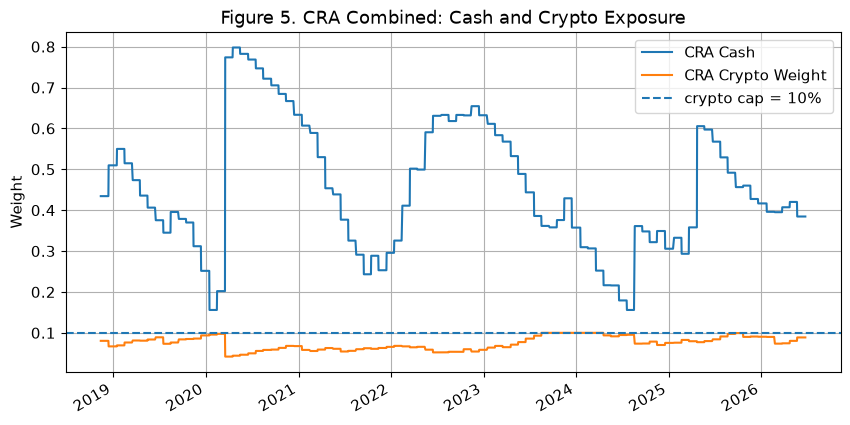

In [11]:
cra_cash = 1 - cra_w.sum(axis=1)
cra_crypto = cra_w[CRYPTO_TICKERS].sum(axis=1)

ax = pd.DataFrame({"CRA Cash": cra_cash, "CRA Crypto Weight": cra_crypto}).plot(
    title="Figure 5. CRA Combined: Cash and Crypto Exposure"
)
ax.axhline(CRYPTO_CAP, linestyle="--", label="crypto cap = 10%")
ax.set_ylabel("Weight")
ax.legend()
plt.show()


### Explanation of Figure 5

- **CRA Crypto Weight** shows the total weight of BTC and ETH;
- the dashed line is the 10% crypto cap;
- **CRA Cash** shows how much capital the model holds in cash.

When the crypto weight often stays close to the 10% dashed line, it means that the crypto cap is a binding constraint. In other words, the model may want to allocate more to crypto, but it is restricted by the 10% upper bound.

When  cash increases, it means that in some periods, in order to satisfy the target volatility, the model reduces risky asset exposure and holds more capital in cash.


## 15. Figure 6: Cash and Crypto Exposure in DD90/10

DD90/10 does not change the relative weights through optimization. Instead, it changes total exposure through $\lambda_t$.


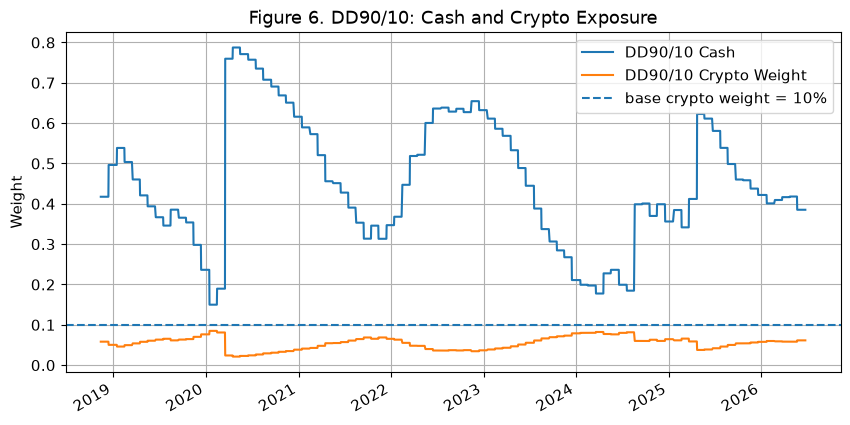

In [12]:
dd_w = weights["DD90/10"]
dd_cash = 1 - dd_w.sum(axis=1)
dd_crypto = dd_w[CRYPTO_TICKERS].sum(axis=1)

ax = pd.DataFrame({"DD90/10 Cash": dd_cash, "DD90/10 Crypto Weight": dd_crypto}).plot(
    title="Figure 6. DD90/10: Cash and Crypto Exposure"
)
ax.axhline(0.10, linestyle="--", label="base crypto weight = 10%")
ax.set_ylabel("Weight")
ax.legend()
plt.show()


### Explanation of Figure 6

This figure shows the dynamic dilution mechanism of DD90/10.

In the base portfolio, the crypto weight is 10%. However, when the estimated volatility is higher than the target, $\lambda_t<1$, so the entire risky portfolio is scaled down. As a result, the actual crypto weight becomes lower than 10%, while cash increases.

> The relative allocation is fixed, but total risk exposure changes with market volatility.


## 16. Figure 7: Final-Period Risk Contribution of CRA

Finally, we check whether CRA is actually controlling risk contribution. We take the final-period weights and compute each asset's risk contribution share.


,Weight,Risk Contribution Share
XLY,0.113720,0.170561
XLI,0.121876,0.169636
XLK,0.095537,0.191803
XLV,0.195619,0.142337
BTC-USD,0.051923,0.161679
ETH-USD,0.036803,0.163983


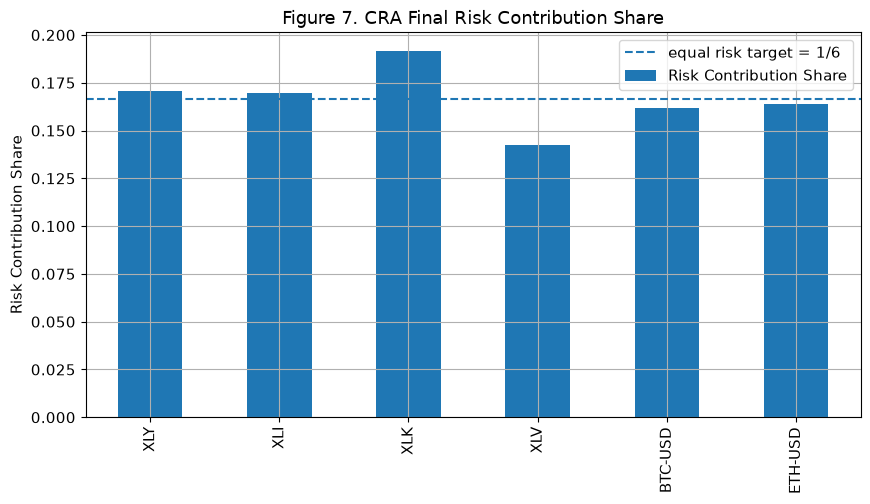

In [13]:
last_date = weights["CRA Combined"].index[-1]
last_hist = returns.loc[:last_date].iloc[-LOOKBACK:]
last_cov = ewma_cov_matrix(last_hist)
last_w = weights["CRA Combined"].iloc[-1]
last_rc = risk_contribution(last_w, last_cov)

rc_table = pd.DataFrame({
    "Weight": last_w,
    "Risk Contribution Share": last_rc
})

display(rc_table)

ax = rc_table["Risk Contribution Share"].plot(kind="bar", title="Figure 7. CRA Final Risk Contribution Share")
ax.axhline(1/len(ALL_TICKERS), linestyle="--", label="equal risk target = 1/6")
ax.set_ylabel("Risk Contribution Share")
ax.legend()
plt.show()


### Explanation of Figure 7

This figure directly tests the core mathematical idea of CRA.

If there are no other interfering constraints, the risk contribution share of the six assets should be close to $1/6$. In practice, the result may not be exactly equal because CRA must also satisfy the target volatility constraint, the crypto cap, and the cash constraint at the same time.

In the presentation, you can emphasize:

> The goal of CRA is not to make capital weights equal, but to make risk contributions close to the target proportions. BTC and ETH may have smaller capital weights, but because of their higher volatility, they may still contribute a risk share close to the target.


## 17. Summarize 
1. **Traditional EW** is the benchmark without crypto exposure.
2. **Fixed 90/10** represents simply adding 10% crypto, without dynamic risk control.
3. **DD90/10** preserves the simple 90/10 structure, but uses cash dilution to control volatility.
4. **CRA Combined** uses the covariance matrix and risk contribution to optimize the portfolio and control risk more systematically.

> Crypto assets can be added to a portfolio, but the key is not to predict their returns. The key is to control their contribution to total risk and increase the cash allocation during high-volatility periods.
